Cell 1: Mount Drive

In [155]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cell 2: Install and Import Libraries

In [156]:
!pip install contractions wordcloud gensim -q

import pandas as pd
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
import time

from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cell 3: Load Dataset

In [157]:
file_path = "/content/drive/MyDrive/datasets/True vs. Fake News Dataset/truevsfakenews.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


Cell 4: Check Dataset and Labels

In [158]:
print(df.info())
print(df.isnull().sum())
print(df['label'].value_counts())

# Remove missing values
df = df.dropna()

# Convert label into number
# true = 1, fake = 0
df['label_num'] = df['label'].map({'true': 1, 'fake': 0})

print(df[['text', 'label', 'label_num']].head())
print(df['label_num'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB
None
text     0
label    0
dtype: int64
label
true    10000
fake    10000
Name: count, dtype: int64
                                                text label  label_num
0  WASHINGTON (Reuters) - The Republican and Demo...  true          1
1  Women should get as far away from Oklahoma as ...  fake          0
2  Another huge crowd of Americans tuned in last ...  fake          0
3  Donald Trump is desperate to stop the investig...  fake          0
4  (Reuters) - Planned Parenthood, the U.S. medic...  true          1
label_num
1    10000
0    10000
Name: count, dtype: int64


Cell 5: Clean Text

In [159]:
stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'said', 'would', 'one', 'also', 'new',
    'reuters', 'trump', 'clinton'
}

stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags symbol
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington republican democratic leader yous s...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake
3,Donald Trump is desperate to stop the investig...,donald desperate stop investigation dirty russ...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",planned parenthood yous medical service provid...,true


Cell 6: Visualize Cleaned Data

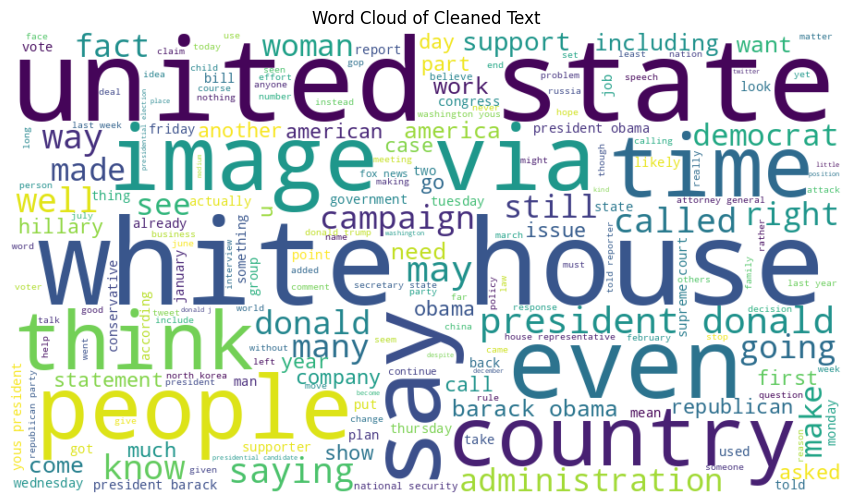

In [160]:
all_words = ' '.join(df['clean_text'])

wordcloud = WordCloud(width=900, height=500, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Text")
plt.show()

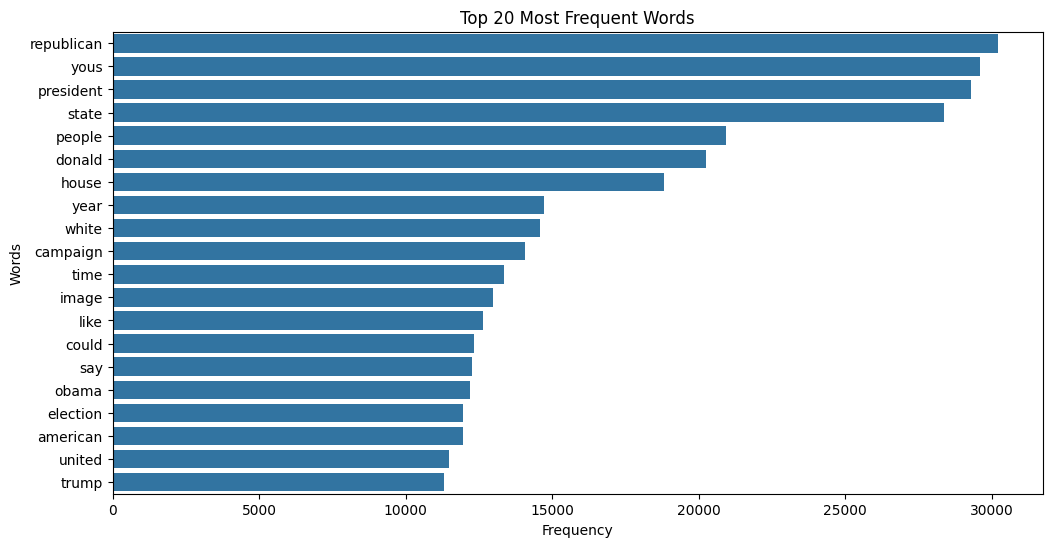

In [161]:
word_counts = Counter(all_words.split())
most_common_words = word_counts.most_common(20)

words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

Cell 7: Train Test Split

In [162]:
X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16000,)
Testing size: (4000,)


Cell 8: Tokenization and Percentile Padding

In [163]:
max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (16000, 100)
Test shape: (4000, 100)


Cell 9: Callbacks

In [164]:
early_stop_rnn = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

early_stop_lstm = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

**4.5.2 Model Building**

Cell 10: Model 1 - Simple RNN

In [165]:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SpatialDropout1D(0.2),

    SimpleRNN(128),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Cell 11: Model 2 - LSTM

In [166]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),

    SpatialDropout1D(0.2),

    Bidirectional(LSTM(64)),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Cell 12: Train Word2Vec

In [177]:
word2vec_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=word2vec_vector_size, # Changed from embedding_dim to word2vec_vector_size
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

word2vec_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

word2vec_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

Cell 13: Create Embedding Matrix

In [168]:
word2vec_vector_size = word2vec_model.vector_size # Get the actual vector size from the trained Word2Vec model
embedding_matrix = np.zeros((vocab_size, word2vec_vector_size)) # Initialize with the correct dimension

word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        if word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


Cell 14: Model 3 - LSTM with Word2Vec

In [169]:
word2vec_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=word2vec_vector_size, # Changed from embedding_dim to word2vec_vector_size
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

word2vec_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

word2vec_lstm_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_26 (Embedding)        │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

**4.5.3 Training and Evaluation**

Cell 15: Train All Models

In [170]:
start = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop_rnn],
    verbose=1
)

rnn_time = time.time() - start

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.8484 - loss: 0.3957 - val_accuracy: 0.9131 - val_loss: 0.2934
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9052 - loss: 0.3030 - val_accuracy: 0.9269 - val_loss: 0.2405
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.9581 - loss: 0.1493 - val_accuracy: 0.9550 - val_loss: 0.1313
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9741 - loss: 0.1088 - val_accuracy: 0.9731 - val_loss: 0.1028
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9846 - loss: 0.0602 - val_accuracy: 0.9750 - val_loss: 0.0933
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9901 - loss: 0.0378 - val_accuracy: 0.9578 - val_loss: 0.1118
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9940 - loss: 0.0249 - val_accuracy: 0.9759 - val_loss: 0.1176
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9938 - loss: 0.03

In [175]:
start = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop_lstm],
    verbose=1
)

lstm_time = time.time() - start

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step - accuracy: 0.9948 - loss: 0.0176 - val_accuracy: 0.9828 - val_loss: 0.0494
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.9828 - val_loss: 0.0584
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9859 - val_loss: 0.0539
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 244ms/step - accuracy: 0.9998 - loss: 8.2587e-04 - val_accuracy: 0.9772 - val_loss: 0.0850
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 244ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9859 - val_loss: 0.0712
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - accuracy: 0.9998 - loss: 5.4951e-04 - val_accuracy: 0.9844 - val_loss: 0.0783


In [178]:
start = time.time()
history_word2vec = word2vec_lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)
word2vec_time = time.time() - start

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.8928 - loss: 0.2929 - val_accuracy: 0.9369 - val_loss: 0.2005
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.9412 - loss: 0.1832 - val_accuracy: 0.9472 - val_loss: 0.1593
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.9313 - loss: 0.1851 - val_accuracy: 0.9569 - val_loss: 0.1355


Cell 16: Plot Accuracy and Loss

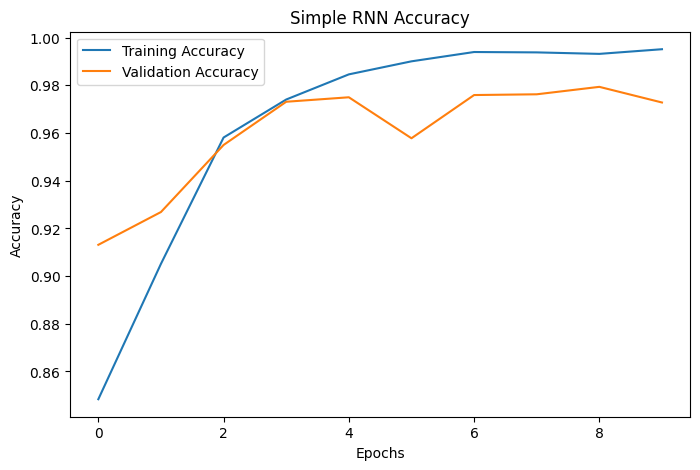

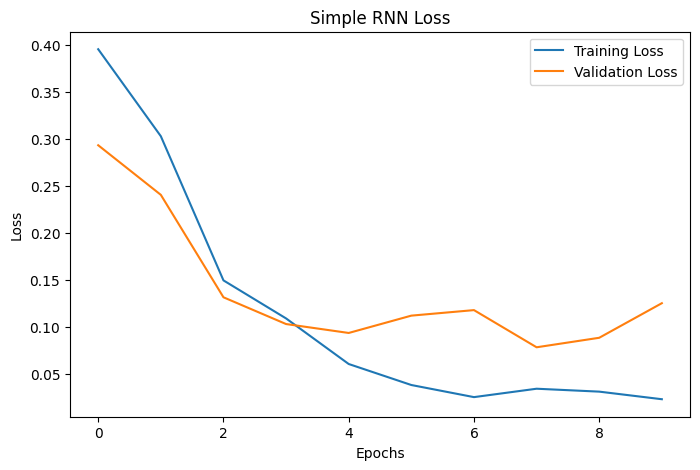

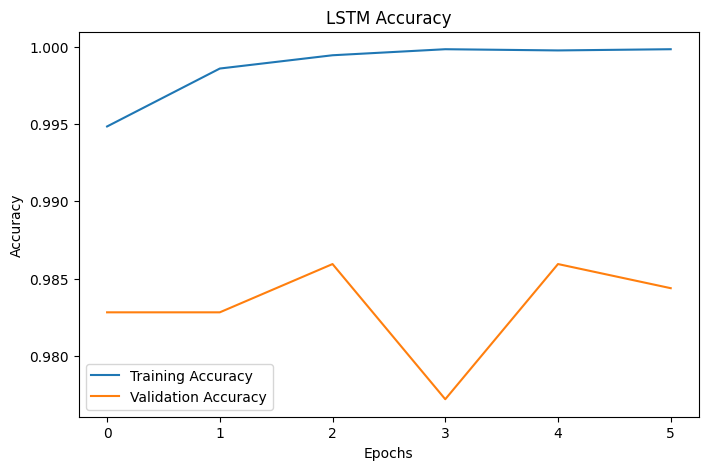

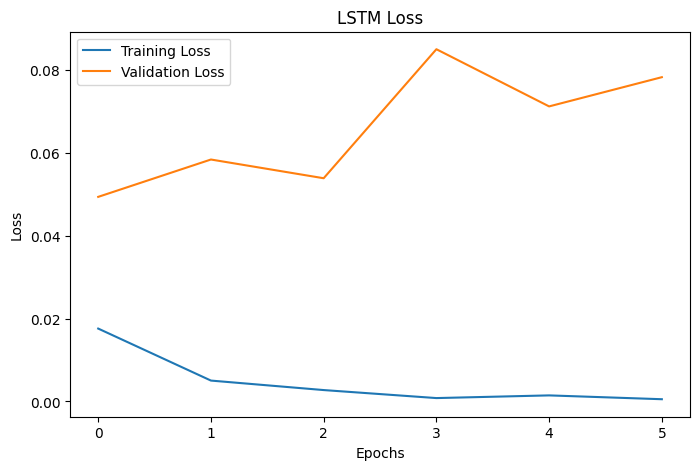

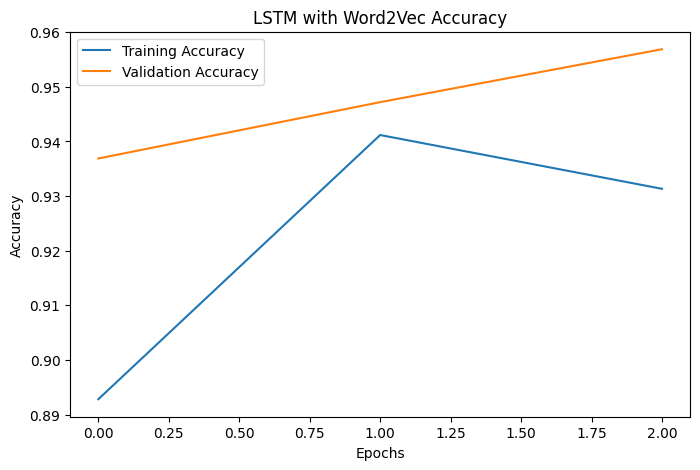

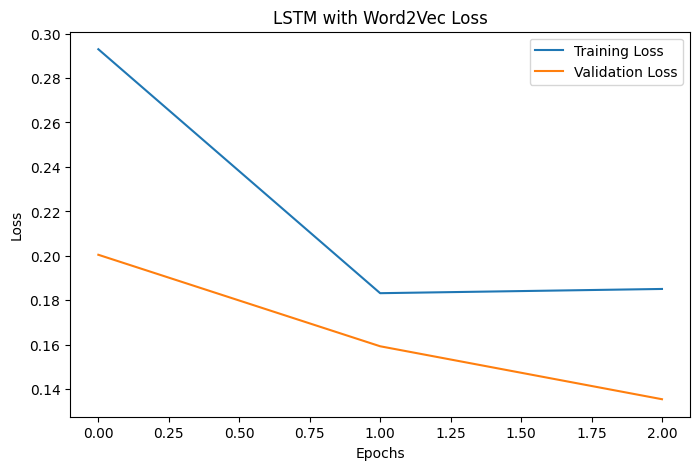

In [179]:
def plot_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_word2vec, "LSTM with Word2Vec")

Cell 17: Evaluate Models

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Simple RNN
Accuracy: 0.9752500057220459
Loss: 0.10164569318294525

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.98      2000
        True       0.98      0.97      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



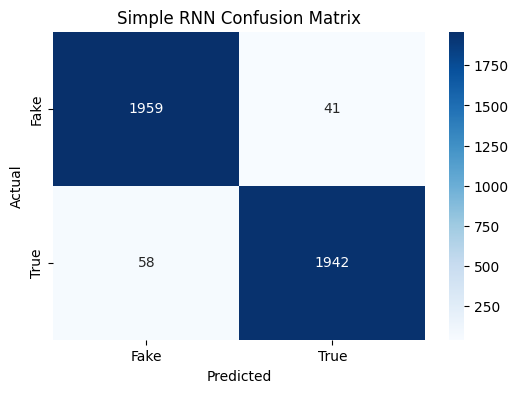

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
LSTM
Accuracy: 0.9792500138282776
Loss: 0.07494895905256271

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.99      0.98      2000
        True       0.99      0.97      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



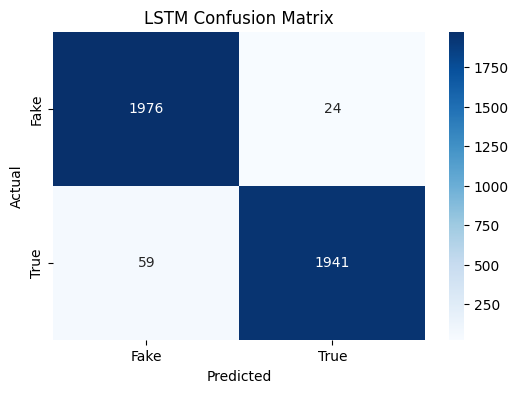

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
LSTM with Word2Vec
Accuracy: 0.9340000152587891
Loss: 0.20068702101707458

Classification Report:
              precision    recall  f1-score   support

        Fake       0.92      0.95      0.94      2000
        True       0.95      0.91      0.93      2000

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



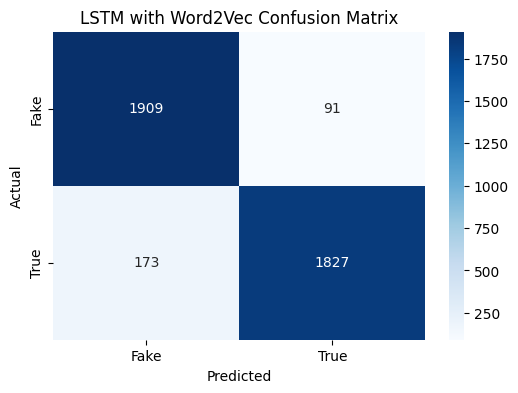

In [180]:
def evaluate_model(model, X_test, y_test, model_name):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print("="*50)
    print(model_name)
    print("Accuracy:", accuracy)
    print("Loss:", loss)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'True'],
                yticklabels=['Fake', 'True'])
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy, loss, y_pred

rnn_acc, rnn_loss, rnn_pred = evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    "Simple RNN"
)
lstm_acc, lstm_loss, lstm_pred = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    "LSTM"
)
word2vec_acc, word2vec_loss, word2vec_pred = evaluate_model(
    word2vec_lstm_model,
    X_test_pad,
    y_test,
    "LSTM with Word2Vec"
)

Cell 18: Compare Model Performance

In [181]:
comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM with Word2Vec'],
    'Accuracy': [rnn_acc, lstm_acc, word2vec_acc],
    'Loss': [rnn_loss, lstm_loss, word2vec_loss],
    'Training Time (seconds)': [rnn_time, lstm_time, word2vec_time]
})

comparison_df

,Model,Accuracy,Loss,Training Time (seconds)
0,Simple RNN,0.97525,0.101646,108.849579
1,LSTM,0.97925,0.074949,176.985001
2,LSTM with Word2Vec,0.93400,0.200687,57.030262


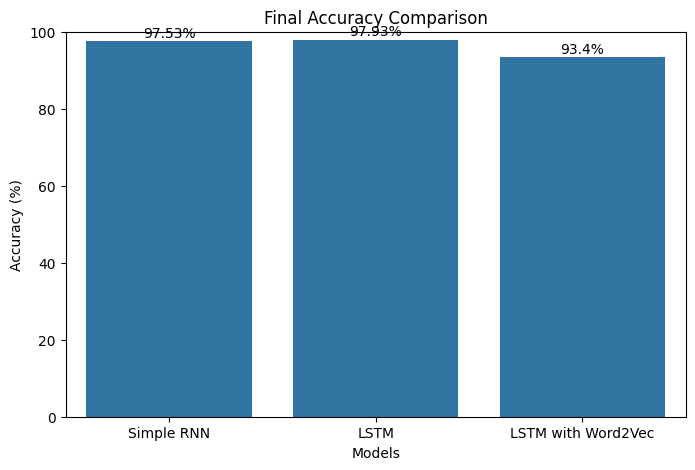

In [189]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=final_results['Model'],
    y=final_results['Accuracy']
)

plt.title("Final Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.ylim(0,100)

for i, value in enumerate(final_results['Accuracy']):
    plt.text(i, value + 1, f"{value}%", ha='center')

plt.show()

Best Model Cell

In [193]:
best_model_name = final_results.loc[
    final_results['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = final_results['Accuracy'].max()

print(f"Best Performing Model: {best_model_name}")
print(f"Highest Accuracy: {best_accuracy}%")

Best Performing Model: LSTM
Highest Accuracy: 97.93%


**4.5.4 Error Analysis**

Cell 19: Incorrect Predictions

In [183]:
best_model = lstm_model
best_pred = lstm_pred

error_df = pd.DataFrame({
    'Original Text': X_test.values,
    'Actual': y_test.values,
    'Predicted': best_pred.flatten()
})

error_df['Actual Label'] = error_df['Actual'].map({0: 'Fake', 1: 'True'})
error_df['Predicted Label'] = error_df['Predicted'].map({0: 'Fake', 1: 'True'})

misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

print("Total Misclassified Examples:", len(misclassified))

misclassified[['Original Text', 'Actual Label', 'Predicted Label']].head(3)

Total Misclassified Examples: 83


,Original Text,Actual Label,Predicted Label
6,johannesburg donald interested rigged election...,True,Fake
199,recent opinion poll carried nbc newswall stree...,Fake,True
224,flint mich pastor black church flint michigan ...,True,Fake


Cell 20: Model Complexity vs Performance Explanation

In [184]:
print("""
Error Analysis:

1. Simple RNN is the simplest model, but it may not remember long text context properly.
2. LSTM performs better because it can remember long-term dependencies in text.
3. LSTM with Word2Vec uses pretrained style embeddings, but performance depends on how well Word2Vec vocabulary matches the dataset.

Possible reasons for incorrect predictions:
- Some fake and true news texts may use similar words.
- The text may be too short or unclear.
- Some important words may be removed during preprocessing.
- Word2Vec may not contain all useful words.
- The model may confuse political or news-related terms.

Potential improvements:
- Use more training data.
- Tune hyperparameters such as LSTM units, batch size, and learning rate.
- Use pretrained embeddings like GloVe.
- Try advanced models like BERT.
- Improve text cleaning carefully without removing important words.
""")


Error Analysis:

1. Simple RNN is the simplest model, but it may not remember long text context properly.
2. LSTM performs better because it can remember long-term dependencies in text.
3. LSTM with Word2Vec uses pretrained style embeddings, but performance depends on how well Word2Vec vocabulary matches the dataset.

Possible reasons for incorrect predictions:
- Some fake and true news texts may use similar words.
- The text may be too short or unclear.
- Some important words may be removed during preprocessing.
- Word2Vec may not contain all useful words.
- The model may confuse political or news-related terms.

Potential improvements:
- Use more training data.
- Tune hyperparameters such as LSTM units, batch size, and learning rate.
- Use pretrained embeddings like GloVe.
- Try advanced models like BERT.
- Improve text cleaning carefully without removing important words.



**4.5.5 GUI for Real-Time Prediction**

Cell 21: Install Gradio

In [185]:
!pip install gradio -q

Cell 22: Real-Time Prediction GUI

In [186]:
import gradio as gr

def predict_news(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    prediction = lstm_model.predict(padded)[0][0]

    if prediction >= 0.5:
        label = "True News"
    else:
        label = "Fake News"

    confidence = prediction if prediction >= 0.5 else 1 - prediction

    return label, float(confidence)

interface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=5, placeholder="Enter a news/tweet text here..."),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Number(label="Confidence")
    ],
    title="Fake vs True News Prediction",
    description="Enter text and the trained LSTM model will predict whether it is Fake or True news."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf15312c124baf8b9a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Final small cell: Save Best Model

In [191]:
lstm_model.save("fake_true_news_lstm_model.h5")
print("Model saved successfully")

Model saved successfully
